## Importing Libraries 

In [12]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
df = pd.read_parquet(r"D:\women_safety_AI\data\train-00000-of-00001.parquet")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 8)


In [14]:
df.head()

,scenario,language,risk_type,severity,reasoning,recommended_action,legal_context,confidence
0,A 25-year-old woman from Hyderabad reported an...,English,coercive control,high,This case constitutes coercive control based o...,Contact Shakti Shalini (011-24373736) or the N...,"BNS Section 85 (cruelty by husband/relatives),...",0.88
1,A 44-year-old woman from Patna reported an inc...,English,coercive control,medium,Analysis confirms coercive control due to the ...,File an FIR at the nearest police station or v...,"BNS Section 85 (cruelty by husband/relatives),...",0.87
2,"In Mumbai, a 51-year-old woman filed a complai...",English,coercive control,medium,Analysis confirms coercive control due to the ...,Contact Shakti Shalini (011-24373736) or the N...,"BNS Section 85 (cruelty by husband/relatives),...",0.97
3,A 35-year-old professional in Pune experienced...,English,coercive control,medium,Analysis confirms coercive control due to the ...,File an FIR at the nearest police station or v...,"BNS Section 85 (cruelty by husband/relatives),...",0.97
4,A 35-year-old professional in Kolkata experien...,English,domestic violence,medium,Analysis confirms domestic violence due to the...,Contact Shakti Shalini (011-24373736) or the N...,Protection of Women from Domestic Violence Act...,0.98


In [15]:
df.tail()

,scenario,language,risk_type,severity,reasoning,recommended_action,legal_context,confidence
995,A 32-year-old woman from Coimbatore reported a...,English,emotional manipulation,medium,This case constitutes emotional manipulation b...,File an FIR at the nearest police station or v...,"PWDVA Section 3(c) (emotional abuse), BNS Sect...",0.96
996,A 31-year-old woman from Patna reported an inc...,English,emotional manipulation,high,This case constitutes emotional manipulation b...,"Preserve all digital evidence (screenshots, ca...","PWDVA Section 3(c) (emotional abuse), BNS Sect...",0.96
997,"In Bhopal, a 27-year-old woman filed a complai...",English,deepfake abuse,critical,This case constitutes deepfake abuse based on ...,Contact Shakti Shalini (011-24373736) or the N...,"IT Act Section 67A, BNS Section 73 (outraging ...",0.88
998,A 47-year-old woman from Delhi reported an inc...,English,blackmail / extortion,critical,This case constitutes blackmail / extortion ba...,File an FIR at the nearest police station or v...,"BNS Section 308(4) (extortion), IT Act Section...",0.94
999,"In Mumbai, a 32-year-old woman filed a complai...",English,online harassment,critical,This case constitutes online harassment based ...,File an FIR at the nearest police station or v...,"BNS Section 351 (criminal intimidation), IT Ac...",0.93


In [16]:
df.columns

Index(['scenario', 'language', 'risk_type', 'severity', 'reasoning',
       'recommended_action', 'legal_context', 'confidence'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scenario            1000 non-null   str    
 1   language            1000 non-null   str    
 2   risk_type           1000 non-null   str    
 3   severity            1000 non-null   str    
 4   reasoning           1000 non-null   str    
 5   recommended_action  1000 non-null   str    
 6   legal_context       1000 non-null   str    
 7   confidence          1000 non-null   float64
dtypes: float64(1), str(7)
memory usage: 789.6 KB


In [18]:
print("Risk Type Distribution:")
print(df["risk_type"].value_counts())  ## to check how many categories are there in the risk_type column

print("\nSeverity Distribution:")
print(df["severity"].value_counts())

Risk Type Distribution:
risk_type
cyberstalking               96
blackmail / extortion       93
public safety / stalking    92
workplace harassment        89
domestic violence           84
online harassment           81
financial exploitation      81
trafficking indicators      80
coercive control            79
deepfake abuse              77
revenge content (NCII)      76
emotional manipulation      72
Name: count, dtype: int64

Severity Distribution:
severity
medium      262
critical    260
high        245
low         233
Name: count, dtype: int64


In [19]:
print("Number of Risk Types:", df["risk_type"].nunique())
print("\nRisk Types:")
print(df["risk_type"].unique())

Number of Risk Types: 12

Risk Types:
<ArrowStringArray>
[        'coercive control',        'domestic violence',
           'deepfake abuse',        'online harassment',
            'cyberstalking',   'financial exploitation',
     'workplace harassment',   'revenge content (NCII)',
   'trafficking indicators',    'blackmail / extortion',
 'public safety / stalking',   'emotional manipulation']
Length: 12, dtype: str


In [20]:
print("Number of Languages:", df["language"].nunique())
print("\nLanguages:")
print(df["language"].value_counts())

Number of Languages: 1

Languages:
language
English    1000
Name: count, dtype: int64


In [21]:
X = df["scenario"]

In [22]:
y = df["risk_type"]

## train and test 

In [23]:
from sklearn.model_selection import train_test_split

X = df["scenario"]
y = df["risk_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [24]:
# Import the function used to split our dataset
from sklearn.model_selection import train_test_split

# Input feature: the woman's safety situation
X = df["scenario"]

# Target: the type of safety risk
y = df["risk_type"]

# Split the data into training and testing sets
# 80% of the data will be used for training
# 20% will be used for testing
# stratify=y keeps the class distribution balanced
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of samples in each set
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


## NLP - TF-IDF Vectorization

In [25]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
# max_features limits the number of text features
# ngram_range=(1, 2) uses both single words and two-word combinations
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

# Learn the vocabulary only from the training data
# This prevents information from the test data leaking into training
X_train_tfidf = vectorizer.fit_transform(X_train)

# Convert the test text using the vocabulary learned from training
X_test_tfidf = vectorizer.transform(X_test)

# Display the shape of the converted data
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 592)
Testing TF-IDF shape: (200, 592)


In [26]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the classification model
# max_iter=1000 gives the model enough iterations to learn
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the TF-IDF training data
model.fit(X_train_tfidf, y_train)

# Print confirmation
print("Risk-type classification model trained successfully!")

Risk-type classification model trained successfully!


Step 7 — Test the Risk-Type Model

In [27]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Use the trained model to predict risk types for test data
y_pred = model.predict(X_test_tfidf)

# Calculate the overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Model Accuracy:", accuracy)

# Display detailed performance for each risk type
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:
                          precision    recall  f1-score   support

   blackmail / extortion       1.00      1.00      1.00        19
        coercive control       1.00      1.00      1.00        16
           cyberstalking       1.00      1.00      1.00        19
          deepfake abuse       1.00      1.00      1.00        15
       domestic violence       1.00      1.00      1.00        17
  emotional manipulation       1.00      1.00      1.00        15
  financial exploitation       1.00      1.00      1.00        16
       online harassment       1.00      1.00      1.00        16
public safety / stalking       1.00      1.00      1.00        18
  revenge content (NCII)       1.00      1.00      1.00        15
  trafficking indicators       1.00      1.00      1.00        16
    workplace harassment       1.00      1.00      1.00        18

                accuracy                           1.00       200
               macro avg      

Step 8 — Confusion Matrix
Now we visually check which risk types the model is confusing with each other.

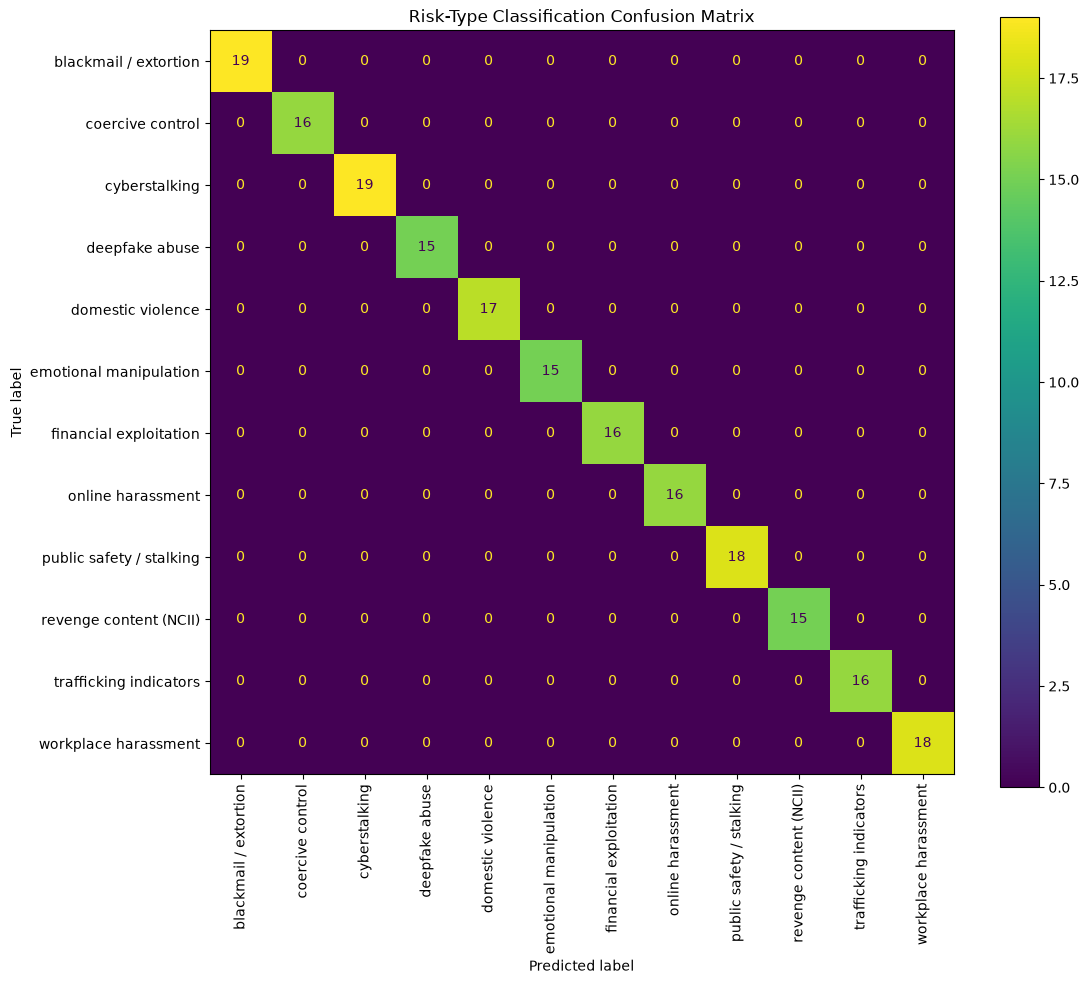

In [30]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# Create a visual display of the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=90)

# Add a title
plt.title("Risk-Type Classification Confusion Matrix")

# Display the plot
plt.show()

Step 9 — Test with New Situations
Now we do something very important: test the model with new text that was not in the dataset.

In [31]:
# Create some new safety situations for testing
new_situations = [
    "A man keeps following me whenever I leave my office.",
    "Someone is threatening to share my private photos online.",
    "My husband controls my money and does not allow me to work.",
    "A coworker keeps making unwanted comments about my body."
]

# Convert the new text into TF-IDF features
new_situations_tfidf = vectorizer.transform(new_situations)

# Predict the risk type for each situation
predictions = model.predict(new_situations_tfidf)

# Display the results
for situation, prediction in zip(new_situations, predictions):
    print("Situation:", situation)
    print("Predicted Risk Type:", prediction)
    print("-" * 60)

Situation: A man keeps following me whenever I leave my office.
Predicted Risk Type: cyberstalking
------------------------------------------------------------
Situation: Someone is threatening to share my private photos online.
Predicted Risk Type: online harassment
------------------------------------------------------------
Situation: My husband controls my money and does not allow me to work.
Predicted Risk Type: cyberstalking
------------------------------------------------------------
Situation: A coworker keeps making unwanted comments about my body.
Predicted Risk Type: cyberstalking
------------------------------------------------------------


Step 10 — Check Prediction Confidence

In [32]:
# Get the probability of every risk type
prediction_probabilities = model.predict_proba(new_situations_tfidf)

# Get the highest probability for each situation
confidence_scores = prediction_probabilities.max(axis=1)

# Display the prediction and confidence
for situation, prediction, confidence in zip(
    new_situations,
    predictions,
    confidence_scores
):
    print("Situation:", situation)
    print("Predicted Risk Type:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Situation: A man keeps following me whenever I leave my office.
Predicted Risk Type: cyberstalking
Confidence: 10.36 %
------------------------------------------------------------
Situation: Someone is threatening to share my private photos online.
Predicted Risk Type: online harassment
Confidence: 87.96 %
------------------------------------------------------------
Situation: My husband controls my money and does not allow me to work.
Predicted Risk Type: cyberstalking
Confidence: 10.98 %
------------------------------------------------------------
Situation: A coworker keeps making unwanted comments about my body.
Predicted Risk Type: cyberstalking
Confidence: 10.36 %
------------------------------------------------------------


Step 11 — Check the Training Examples
We will search our dataset for examples belonging to:
- cyberstalking
- financial exploitation
- workplace harassment
- public safety / stalking

In [33]:
# Check some examples from important risk categories
categories_to_check = [
    "cyberstalking",
    "financial exploitation",
    "workplace harassment",
    "public safety / stalking"
]

# Display sample scenarios from each category
for category in categories_to_check:
    print("\n" + "=" * 70)
    print("CATEGORY:", category)
    print("=" * 70)

    # Get 5 examples from this category
    examples = df[df["risk_type"] == category]["scenario"].head(5)

    # Print the examples
    for i, example in enumerate(examples, start=1):
        print(f"{i}. {example}")


CATEGORY: cyberstalking
1. A 44-year-old professional in Hyderabad experienced cyberstalking. The situation was assessed as high severity. She had documented evidence and approached the local cyber cell for assistance.
2. In Coimbatore, a 45-year-old woman filed a complaint regarding cyberstalking. The harm caused was classified as critical. She was advised on legal remedies and support organizations available in her area.
3. A 35-year-old professional in Lucknow experienced cyberstalking. The situation was assessed as critical severity. She had documented evidence and approached the local cyber cell for assistance.
4. A 18-year-old professional in Pune experienced cyberstalking. The situation was assessed as medium severity. She had documented evidence and approached the local cyber cell for assistance.
5. In Pune, a 27-year-old woman filed a complaint regarding cyberstalking. The harm caused was classified as low. She was advised on legal remedies and support organizations available

In [34]:
# Create realistic user-style examples
# These examples are written the way a real user might describe a situation.

extra_data = pd.DataFrame({

    "scenario": [
        # Public safety / stalking
        "A man keeps following me whenever I leave my office.",
        "Someone follows me every day when I walk home.",
        "A stranger keeps waiting outside my house.",
        "I think someone is stalking me and following me everywhere.",

        # Financial exploitation
        "My husband controls my money and does not allow me to work.",
        "My partner takes my salary and controls all my bank accounts.",
        "Someone is forcing me to give them my money.",
        "My family member is taking my money without my permission.",

        # Workplace harassment
        "A coworker keeps making unwanted comments about my body.",
        "My manager keeps making inappropriate comments about me.",
        "A colleague makes sexual jokes about me at work.",
        "Someone at my workplace keeps making me uncomfortable.",

        # Cyberstalking
        "Someone keeps sending me messages and tracking me online.",
        "A person keeps monitoring my social media accounts.",
        "Someone is constantly messaging me and following my online activity.",
        "I keep receiving unwanted messages from the same person online."
    ],

    "risk_type": [
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",

        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",

        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",

        "cyberstalking",
        "cyberstalking",
        "cyberstalking",
        "cyberstalking"
    ]
})

# Display the new examples
print("New examples created:", len(extra_data))
print(extra_data)

New examples created: 16
                                             scenario  \
0   A man keeps following me whenever I leave my o...   
1      Someone follows me every day when I walk home.   
2          A stranger keeps waiting outside my house.   
3   I think someone is stalking me and following m...   
4   My husband controls my money and does not allo...   
5   My partner takes my salary and controls all my...   
6        Someone is forcing me to give them my money.   
7   My family member is taking my money without my...   
8   A coworker keeps making unwanted comments abou...   
9   My manager keeps making inappropriate comments...   
10   A colleague makes sexual jokes about me at work.   
11  Someone at my workplace keeps making me uncomf...   
12  Someone keeps sending me messages and tracking...   
13  A person keeps monitoring my social media acco...   
14  Someone is constantly messaging me and followi...   
15  I keep receiving unwanted messages from the sa...   

     

Step 13 — Add the New Examples to Training Data

In [35]:
# Convert the original training data into a DataFrame
train_data = pd.DataFrame({
    "scenario": X_train.values,
    "risk_type": y_train.values
})

# Add our new realistic examples to the training data
train_data = pd.concat(
    [train_data, extra_data],
    ignore_index=True
)

# Separate the input text and target labels again
X_train = train_data["scenario"]
y_train = train_data["risk_type"]

# Display the new training dataset size
print("New training samples:", len(X_train))
print("Test samples:", len(X_test))

New training samples: 816
Test samples: 200


Step 14 — Recreate TF-IDF with the Improved Training Data

In [36]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a new TF-IDF vectorizer
# Unigrams = individual words
# Bigrams = two-word combinations
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

# Learn vocabulary from the improved training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Convert the original test data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

# Display the new feature sizes
print("Updated training TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Updated training TF-IDF shape: (816, 775)
Test TF-IDF shape: (200, 775)


Step 15 — Retrain the Model

In [37]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create a new Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the improved training data
model.fit(X_train_tfidf, y_train)

# Display confirmation
print("Improved risk-type model trained successfully!")

Improved risk-type model trained successfully!


Step 16 — Test the Improved Model

In [38]:
# Convert our new real-world situations into TF-IDF features
new_situations_tfidf = vectorizer.transform(new_situations)

# Predict the risk type for each situation
improved_predictions = model.predict(new_situations_tfidf)

# Get the prediction confidence
improved_probabilities = model.predict_proba(new_situations_tfidf)
improved_confidence = improved_probabilities.max(axis=1)

# Display the results
for situation, prediction, confidence in zip(
    new_situations,
    improved_predictions,
    improved_confidence
):
    print("Situation:", situation)
    print("Predicted Risk Type:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Situation: A man keeps following me whenever I leave my office.
Predicted Risk Type: public safety / stalking
Confidence: 25.09 %
------------------------------------------------------------
Situation: Someone is threatening to share my private photos online.
Predicted Risk Type: financial exploitation
Confidence: 19.06 %
------------------------------------------------------------
Situation: My husband controls my money and does not allow me to work.
Predicted Risk Type: financial exploitation
Confidence: 30.93 %
------------------------------------------------------------
Situation: A coworker keeps making unwanted comments about my body.
Predicted Risk Type: workplace harassment
Confidence: 30.2 %
------------------------------------------------------------


Step 17 — Add More Realistic Examples

In [39]:
# Create more realistic user-style examples
# These examples represent how users may naturally describe their problems.

more_examples = pd.DataFrame({

    "scenario": [

        # ---------------- STALKING ----------------
        "A man follows me whenever I go outside.",
        "Someone is following me on my way home.",
        "A person keeps waiting outside my house.",
        "I am being followed by someone every day.",
        "Someone keeps watching me wherever I go.",
        "A stranger follows me when I leave work.",
        "I feel like someone is stalking me.",
        "Someone keeps coming after me wherever I travel.",

        # ---------------- FINANCIAL EXPLOITATION ----------------
        "My partner takes my salary without asking me.",
        "Someone is forcing me to give them money.",
        "My husband controls my bank account and my salary.",
        "My partner does not allow me to control my own money.",
        "Someone is using my bank account without permission.",
        "My family member is taking my money.",
        "I am being forced to hand over my earnings.",
        "My partner controls all my financial decisions.",

        # ---------------- WORKPLACE HARASSMENT ----------------
        "My coworker keeps making inappropriate comments about me.",
        "A colleague makes unwanted sexual comments at work.",
        "My manager keeps making uncomfortable comments about my body.",
        "Someone at work keeps making inappropriate jokes about me.",
        "A coworker keeps making me uncomfortable at the office.",
        "My colleague keeps commenting on my appearance.",
        "I am being harassed by someone at my workplace.",
        "My boss makes unwanted personal comments about me.",

        # ---------------- REVENGE CONTENT / NCII ----------------
        "Someone is threatening to post my private photos online.",
        "My ex is threatening to share my intimate pictures.",
        "Someone has my private photos and is threatening to publish them.",
        "A person is blackmailing me with my private pictures.",
        "Someone is threatening to upload my intimate photos.",
        "My ex says they will post my private images.",
        "Someone is threatening to share my personal videos.",
        "I am being threatened with the release of private photos."
    ],

    "risk_type": [

        # Stalking
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",
        "public safety / stalking",

        # Financial exploitation
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",
        "financial exploitation",

        # Workplace harassment
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",
        "workplace harassment",

        # Revenge content / NCII
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)",
        "revenge content (NCII)"
    ]
})

# Display the number of new examples
print("Additional examples created:", len(more_examples))

Additional examples created: 32


🧙🏾‍♂️ Step 18 — Add the New Examples to Training Data

In [40]:
# Add the new realistic examples to our existing training data
train_data = pd.concat(
    [train_data, more_examples],
    ignore_index=True
)

# Update the training input and target variables
X_train = train_data["scenario"]
y_train = train_data["risk_type"]

# Display the updated training size
print("Updated training samples:", len(X_train))
print("Test samples:", len(X_test))

Updated training samples: 848
Test samples: 200


Step 18 — Recreate TF-IDF

In [41]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

# Learn vocabulary from our updated training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vocabulary
X_test_tfidf = vectorizer.transform(X_test)

# Display the shapes
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (848, 937)
Testing TF-IDF shape: (200, 937)


Step 19 — Train the Final Risk-Type Model

In [42]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the final risk-type classification model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

# Confirm training is complete
print("Final risk-type model trained successfully!")

Final risk-type model trained successfully!


Step 20 — Evaluate the Final Risk-Type Model 

In [43]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Predict risk types for the test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Final Model Accuracy:", accuracy)

# Display detailed performance
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Model Accuracy: 1.0

Classification Report:
                          precision    recall  f1-score   support

   blackmail / extortion       1.00      1.00      1.00        19
        coercive control       1.00      1.00      1.00        16
           cyberstalking       1.00      1.00      1.00        19
          deepfake abuse       1.00      1.00      1.00        15
       domestic violence       1.00      1.00      1.00        17
  emotional manipulation       1.00      1.00      1.00        15
  financial exploitation       1.00      1.00      1.00        16
       online harassment       1.00      1.00      1.00        16
public safety / stalking       1.00      1.00      1.00        18
  revenge content (NCII)       1.00      1.00      1.00        15
  trafficking indicators       1.00      1.00      1.00        16
    workplace harassment       1.00      1.00      1.00        18

                accuracy                           1.00       200
               macro avg

Step 21 — Test the Final Model with Real-World Situations

In [44]:
# Convert the real-world situations into TF-IDF features
new_situations_tfidf = vectorizer.transform(new_situations)

# Predict the risk type
final_predictions = model.predict(new_situations_tfidf)

# Get prediction probabilities
final_probabilities = model.predict_proba(new_situations_tfidf)

# Get the highest confidence for each prediction
final_confidence = final_probabilities.max(axis=1)

# Display the results
for situation, prediction, confidence in zip(
    new_situations,
    final_predictions,
    final_confidence
):
    print("Situation:", situation)
    print("Predicted Risk Type:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Situation: A man keeps following me whenever I leave my office.
Predicted Risk Type: public safety / stalking
Confidence: 37.5 %
------------------------------------------------------------
Situation: Someone is threatening to share my private photos online.
Predicted Risk Type: revenge content (NCII)
Confidence: 47.79 %
------------------------------------------------------------
Situation: My husband controls my money and does not allow me to work.
Predicted Risk Type: financial exploitation
Confidence: 47.63 %
------------------------------------------------------------
Situation: A coworker keeps making unwanted comments about my body.
Predicted Risk Type: workplace harassment
Confidence: 52.88 %
------------------------------------------------------------


Step 22 — Train the Severity Classification Model

In [45]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Input feature: safety situation
X_severity = df["scenario"]

# Target: severity level
y_severity = df["severity"]

# Split the data into training and testing sets
# 80% for training and 20% for testing
# stratify keeps the severity distribution balanced
X_severity_train, X_severity_test, y_severity_train, y_severity_test = train_test_split(
    X_severity,
    y_severity,
    test_size=0.20,
    random_state=42,
    stratify=y_severity
)

# Display the sizes
print("Severity training samples:", len(X_severity_train))
print("Severity testing samples:", len(X_severity_test))

Severity training samples: 800
Severity testing samples: 200


Step 23 — Create TF-IDF Features for Severity

In [46]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create a separate TF-IDF vectorizer for severity classification
severity_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

# Learn the vocabulary from severity training data
severity_X_train_tfidf = severity_vectorizer.fit_transform(
    X_severity_train
)

# Transform the severity test data
# We use the vocabulary learned from the training data
severity_X_test_tfidf = severity_vectorizer.transform(
    X_severity_test
)

# Display the feature shapes
print(
    "Severity training TF-IDF shape:",
    severity_X_train_tfidf.shape
)

print(
    "Severity testing TF-IDF shape:",
    severity_X_test_tfidf.shape
)

Severity training TF-IDF shape: (800, 594)
Severity testing TF-IDF shape: (200, 594)


Step 24 — Train the Severity Model

In [47]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the severity classification model
severity_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the severity training data
severity_model.fit(
    severity_X_train_tfidf,
    y_severity_train
)

# Confirm training is complete
print("Severity classification model trained successfully!")

Severity classification model trained successfully!


Step 25 — Evaluate the Severity Model

In [48]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Predict severity for the test data
severity_predictions = severity_model.predict(
    severity_X_test_tfidf
)

# Calculate accuracy
severity_accuracy = accuracy_score(
    y_severity_test,
    severity_predictions
)

# Display the accuracy
print("Severity Model Accuracy:", severity_accuracy)

# Display detailed performance
print("\nSeverity Classification Report:")
print(
    classification_report(
        y_severity_test,
        severity_predictions
    )
)

Severity Model Accuracy: 1.0

Severity Classification Report:
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        52
        high       1.00      1.00      1.00        49
         low       1.00      1.00      1.00        47
      medium       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Step 26 — Test Both Models Together

In [49]:
# Create one new safety situation
test_situation = [
    "A stranger keeps following me every evening when I return home."
]

# ---------------- RISK TYPE ----------------

# Convert the situation using the risk TF-IDF vectorizer
risk_features = vectorizer.transform(test_situation)

# Predict the risk type
predicted_risk = model.predict(risk_features)[0]

# Get risk confidence
risk_probabilities = model.predict_proba(risk_features)
risk_confidence = risk_probabilities.max()

# ---------------- SEVERITY ----------------

# Convert the same situation using the severity TF-IDF vectorizer
severity_features = severity_vectorizer.transform(test_situation)

# Predict severity
predicted_severity = severity_model.predict(
    severity_features
)[0]

# Get severity confidence
severity_probabilities = severity_model.predict_proba(
    severity_features
)
severity_confidence = severity_probabilities.max()

# ---------------- DISPLAY RESULTS ----------------

print("Situation:", test_situation[0])

print("\nPredicted Risk Type:", predicted_risk)
print("Risk Confidence:", round(risk_confidence * 100, 2), "%")

print("\nPredicted Severity:", predicted_severity)
print("Severity Confidence:", round(severity_confidence * 100, 2), "%")

Situation: A stranger keeps following me every evening when I return home.

Predicted Risk Type: public safety / stalking
Risk Confidence: 40.31 %

Predicted Severity: medium
Severity Confidence: 25.79 %


Step 27 — Create a Reusable Prediction Function

In [50]:
def analyze_situation(situation):
    """
    Analyze a user's safety situation.

    Input:
        situation - text describing the user's problem

    Output:
        risk_type
        risk_confidence
        severity
        severity_confidence
    """

    # Convert the user's text into risk-model TF-IDF features
    risk_features = vectorizer.transform([situation])

    # Predict the risk type
    risk_type = model.predict(risk_features)[0]

    # Get risk prediction confidence
    risk_probabilities = model.predict_proba(risk_features)
    risk_confidence = risk_probabilities.max()

    # Convert the user's text into severity-model TF-IDF features
    severity_features = severity_vectorizer.transform([situation])

    # Predict the severity
    severity = severity_model.predict(severity_features)[0]

    # Get severity prediction confidence
    severity_probabilities = severity_model.predict_proba(
        severity_features
    )
    severity_confidence = severity_probabilities.max()

    # Return all results
    return {
        "risk_type": risk_type,
        "risk_confidence": round(risk_confidence * 100, 2),
        "severity": severity,
        "severity_confidence": round(severity_confidence * 100, 2)
    }

In [51]:
# Test the reusable prediction function

result = analyze_situation(
    "Someone keeps following me when I return home."
)

print(result)

{'risk_type': 'public safety / stalking', 'risk_confidence': np.float64(41.21), 'severity': 'medium', 'severity_confidence': np.float64(25.79)}


Step 28 — Save the Trained ML Models

In [52]:
# Import joblib for saving Python ML objects
import joblib

# Create a folder to store our trained ML files
import os
os.makedirs("models", exist_ok=True)

# Save the risk-type model
joblib.dump(
    model,
    "models/risk_model.pkl"
)

# Save the risk-type TF-IDF vectorizer
joblib.dump(
    vectorizer,
    "models/risk_vectorizer.pkl"
)

# Save the severity model
joblib.dump(
    severity_model,
    "models/severity_model.pkl"
)

# Save the severity TF-IDF vectorizer
joblib.dump(
    severity_vectorizer,
    "models/severity_vectorizer.pkl"
)

print("All ML models and vectorizers saved successfully!")

All ML models and vectorizers saved successfully!


Step 29 — Verify the Saved Models

In [53]:
# Import joblib to load the saved models
import joblib

# Load the saved risk model
loaded_risk_model = joblib.load(
    "models/risk_model.pkl"
)

# Load the saved risk vectorizer
loaded_risk_vectorizer = joblib.load(
    "models/risk_vectorizer.pkl"
)

# Load the saved severity model
loaded_severity_model = joblib.load(
    "models/severity_model.pkl"
)

# Load the saved severity vectorizer
loaded_severity_vectorizer = joblib.load(
    "models/severity_vectorizer.pkl"
)

print("All saved models loaded successfully!")

All saved models loaded successfully!


In [54]:
# Test situation
test_text = "Someone keeps following me when I return home."

# Convert text using the saved risk vectorizer
risk_features = loaded_risk_vectorizer.transform([test_text])

# Predict risk type
risk_prediction = loaded_risk_model.predict(
    risk_features
)[0]

# Convert text using the saved severity vectorizer
severity_features = loaded_severity_vectorizer.transform([test_text])

# Predict severity
severity_prediction = loaded_severity_model.predict(
    severity_features
)[0]

# Display results
print("Situation:", test_text)
print("Risk Type:", risk_prediction)
print("Severity:", severity_prediction)

Situation: Someone keeps following me when I return home.
Risk Type: public safety / stalking
Severity: medium
